# Long-Form ASQA Evaluation

Compares models on ASQA (Ambiguous Short-answer QA) using two metrics:
- **EM-Recall** — fraction of gold short-answers found anywhere in the predicted output
- **ROUGE-L** — F1 overlap against the gold long-form annotation

Mode: `always_retrieve` | Retriever: GTR top-100

Both models are evaluated on the **same subset of examples** (intersection of questions both models produced outputs for), so the comparison is fair.

In [1]:
# CONFIG
import os

# Gold annotation file (ASQA eval set)
GOLD_FILE = "longform_data/asqa_eval_gtr_top100.json"

# Model prediction files — add/remove models as needed
# Values can be full paths or relative to where you run the notebook
PRED_FILES = {
    "Base Self-RAG":  "longform_data/base_asqa.json",
    "Critic-10K PPO": "longform_data/critic10k_asqa.json",
}

# Output figure filename
FIG_BAR  = "longform_asqa_eval.png"
FIG_DIST = "longform_asqa_distribution.png"

# Bar chart y-axis limits (adjust if scores are out of range)
EM_YLIM = 40
RL_YLIM = 35

# Colors — one per model in order
COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

In [2]:
import json, string, re, unicodedata
import numpy as np
import matplotlib.pyplot as plt

# Text normalization helpers
def normalize(s):
    s = unicodedata.normalize("NFD", s)
    s = s.lower()
    s = re.sub(r"[%s]" % re.escape(string.punctuation), " ", s)
    return " ".join(s.split())

def em_match(answer, text):
    return normalize(answer) in normalize(text)

def lcs_len(a, b):
    m, n = len(a), len(b)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if a[i-1] == b[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[m][n]

def rouge_l(pred, gold):
    p = normalize(pred).split()
    g = normalize(gold).split()
    if not p or not g:
        return 0.0
    l = lcs_len(p, g)
    prec, rec = l / len(p), l / len(g)
    return 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

# Load gold annotations
gold_list  = json.load(open(GOLD_FILE))
gold_by_id = {str(x["sample_id"]): x for x in gold_list}
gold_by_q  = {x["question"]: x for x in gold_list}

def get_gold(item):
    return (gold_by_id.get(str(item.get("sample_id", ""))) or
            gold_by_q.get(item.get("question", "")))

print(f"Gold examples loaded: {len(gold_list)}")

Gold examples loaded: 948


In [3]:
# Load predictions and find the common subset across all models
def get_item_key(item):
    sid = str(item.get("sample_id", "")).strip()
    if sid:
        return ("id", sid)
    return ("q", item.get("question", "").strip())

all_preds  = {}
model_keys = {}

for label, path in PRED_FILES.items():
    # Fall back to _tmp if the full file doesn't exist yet
    load_path = path if os.path.exists(path) else path + "_tmp"
    data  = json.load(open(load_path))
    items = data.get("data", data) if isinstance(data, dict) else data
    valid = [item for item in items if get_gold(item) is not None]
    all_preds[label]  = {get_item_key(item): item for item in valid}
    model_keys[label] = set(all_preds[label].keys())
    print(f"{label}: {len(valid)} examples with gold match (out of {len(items)} total)")

common_keys = set.intersection(*model_keys.values())
print(f"\nComparable examples (all models): {len(common_keys)}")

Base Self-RAG: 948 examples with gold match (out of 948 total)
Critic-10K PPO: 700 examples with gold match (out of 700 total)

Comparable examples (all models): 700


In [4]:
# Evaluate each model on the common subset
def evaluate(label, preds_by_key, keys):
    em_scores, rl_scores = [], []
    for key in keys:
        item = preds_by_key[key]
        g    = get_gold(item)
        if g is None:
            continue
        pred = item.get("output", "")

        qa_pairs = g.get("qa_pairs", [])
        if qa_pairs:
            hits = [float(any(em_match(a, pred) for a in qa.get("short_answers", [])))
                    for qa in qa_pairs]
            em_scores.append(np.mean(hits))

        annots = g.get("annotations", [])
        if annots:
            gold_long = annots[0].get("long_answer", "")
            if gold_long:
                rl_scores.append(rouge_l(pred, gold_long))

    return {
        "label":          label,
        "n_comparable":   len(keys),
        "n_eval":         len(em_scores),
        "em":             np.mean(em_scores) if em_scores else 0.0,
        "rouge_l":        np.mean(rl_scores) if rl_scores else 0.0,
        "em_per_example": em_scores,
        "rl_per_example": rl_scores,
    }

results = {}
for label in PRED_FILES:
    r = evaluate(label, all_preds[label], common_keys)
    results[label] = r
    print(f"{label:<20}  EM-Recall={r['em']*100:.2f}%   ROUGE-L={r['rouge_l']*100:.2f}%   (n={r['n_eval']})")

Base Self-RAG         EM-Recall=31.20%   ROUGE-L=28.35%   (n=700)
Critic-10K PPO        EM-Recall=32.26%   ROUGE-L=28.39%   (n=700)


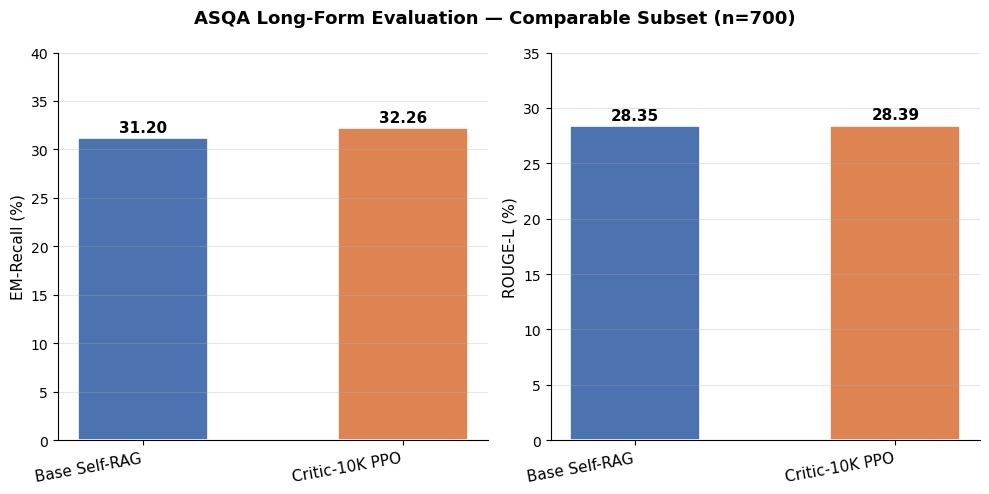

Saved: longform_asqa_eval.png


In [5]:
# Bar chart — EM-Recall and ROUGE-L side by side
labels  = list(results.keys())
em_vals = [r["em"] * 100 for r in results.values()]
rl_vals = [r["rouge_l"] * 100 for r in results.values()]
n_eval  = list(results.values())[0]["n_eval"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle(f"ASQA Long-Form Evaluation — Comparable Subset (n={n_eval})",
             fontsize=13, fontweight="bold")

for ax, vals, metric, ylim in zip(axes,
                                   [em_vals, rl_vals],
                                   ["EM-Recall (%)", "ROUGE-L (%)"],
                                   [EM_YLIM, RL_YLIM]):
    bars = ax.bar(labels, vals, color=COLORS[:len(labels)],
                  width=0.5, edgecolor="white", linewidth=1.2)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_ylim(0, ylim)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=10, ha="right", fontsize=11)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f"{val:.2f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_BAR, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", FIG_BAR)

In [6]:
# Summary numbers table + delta vs first model
baseline = list(results.keys())[0]
col_w    = 16
header   = f"{'Model':<22}" + f"{'EM-Recall (%)':>{col_w}}" + f"{'ROUGE-L (%)':>{col_w}}" + f"{'N eval':>{col_w}}"
sep      = "-" * len(header)

print("ASQA Long-Form Results  (always_retrieve, GTR top-100)")
print(f"Comparable subset: both models evaluated on the same {n_eval} examples")
print()
print(header)
print(sep)

best_em = max(results, key=lambda k: results[k]["em"])
best_rl = max(results, key=lambda k: results[k]["rouge_l"])

for label, r in results.items():
    em_str = f"{r['em']*100:.2f}%"
    rl_str = f"{r['rouge_l']*100:.2f}%"
    if label == best_em: em_str = f"[{em_str}]"
    if label == best_rl: rl_str = f"[{rl_str}]"
    print(f"{label:<22}{em_str:>{col_w}}{rl_str:>{col_w}}{r['n_eval']:>{col_w}}")

print(sep)
print("[value] = best in column")
print()

# Delta vs baseline (first model)
base = results[baseline]
print(f"Delta vs {baseline}:")
for label, r in results.items():
    if label == baseline:
        continue
    print(f"  {label}")
    print(f"    EM-Recall : {(r['em'] - base['em'])*100:+.2f} pp")
    print(f"    ROUGE-L   : {(r['rouge_l'] - base['rouge_l'])*100:+.2f} pp")

ASQA Long-Form Results  (always_retrieve, GTR top-100)
Comparable subset: both models evaluated on the same 700 examples

Model                    EM-Recall (%)     ROUGE-L (%)          N eval
----------------------------------------------------------------------
Base Self-RAG                   31.20%          28.35%             700
Critic-10K PPO                [32.26%]        [28.39%]             700
----------------------------------------------------------------------
[value] = best in column

Delta vs Base Self-RAG:
  Critic-10K PPO
    EM-Recall : +1.05 pp
    ROUGE-L   : +0.05 pp
